In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_excel("../data/Dry_Bean_Dataset.xlsx")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

Dataset loaded successfully!
Dataset shape: (13611, 17)


In [3]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [4]:
df.shape

(13611, 17)

In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 13611
Number of columns: 17


In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 68


In [8]:
print(df.dtypes)

Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRation       float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class                  str
dtype: object


In [9]:
print("Number of classes:", df["Class"].nunique())
print("\nClass names:")
print(df["Class"].unique())

Number of classes: 7

Class names:
<ArrowStringArray>
['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
Length: 7, dtype: str


In [10]:
print(df["Class"].value_counts())

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [11]:
df.shape

(13611, 17)

In [12]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(68)

In [14]:
df["Class"].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

In [15]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (13543, 17)


In [16]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


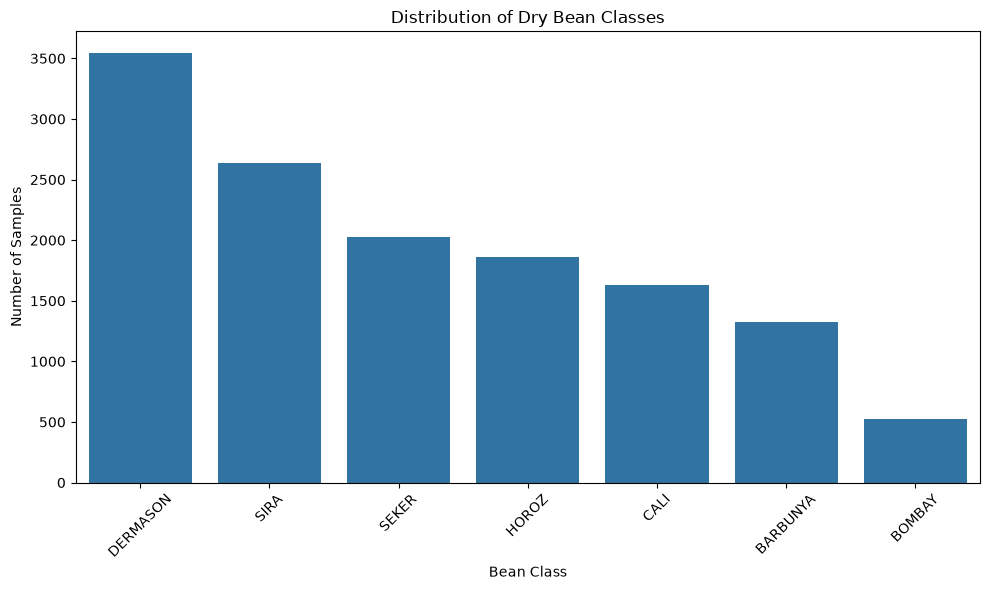

In [17]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Class",
    order=df["Class"].value_counts().index
)

plt.title("Distribution of Dry Bean Classes")
plt.xlabel("Bean Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

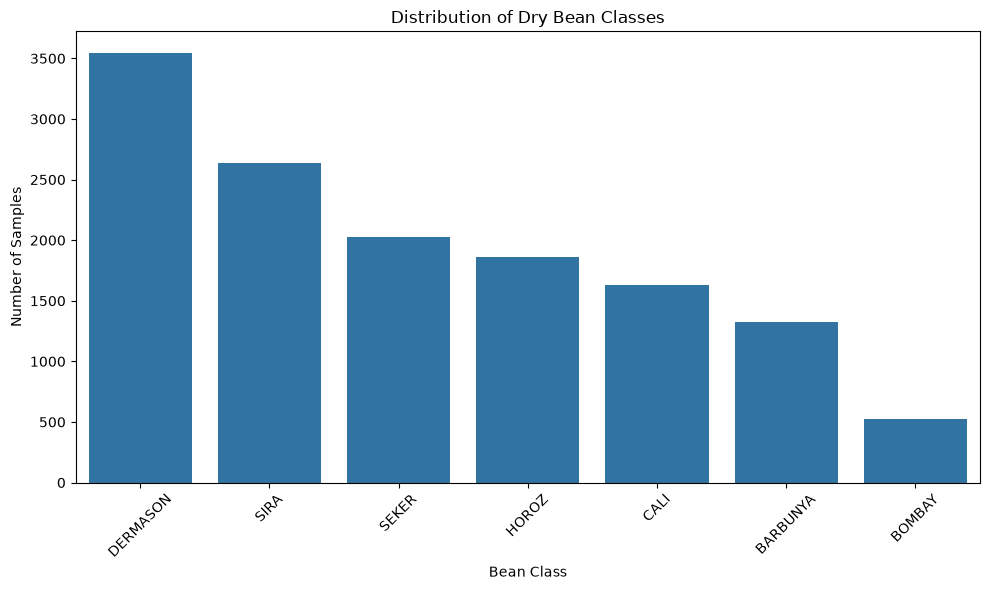

Figure saved successfully!


In [18]:
import os

# Create the figures folder if it does not already exist
os.makedirs("../figures", exist_ok=True)

# Create the class distribution plot
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Class",
    order=df["Class"].value_counts().index
)

plt.title("Distribution of Dry Bean Classes")
plt.xlabel("Bean Class")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.tight_layout()

# Save the figure
plt.savefig("../figures/class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved successfully!")

In [19]:
# Separate features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (13543, 16)
Target shape: (13543,)


In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Original classes:")
print(label_encoder.classes_)

print("\nEncoded classes:")
print(np.unique(y_encoded))

Original classes:
['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']

Encoded classes:
[0 1 2 3 4 5 6]


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (10834, 16)
Testing set: (2709, 16)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (10834, 16)
Scaled testing data shape: (2709, 16)


In [23]:
print("Mean of scaled training features:")
print(np.mean(X_train_scaled, axis=0))

print("\nStandard deviation of scaled training features:")
print(np.std(X_train_scaled, axis=0))

Mean of scaled training features:
[-6.55845243e-17  2.53156264e-16 -1.77078215e-16 -5.21396968e-16
  4.03344824e-17  3.61042806e-16  1.00344322e-16 -4.45318920e-16
 -2.64961478e-16 -2.63715372e-14 -1.19232665e-15  4.81390408e-16
 -4.16789652e-16  1.06246929e-16  7.74881154e-16 -3.57107735e-15]

Standard deviation of scaled training features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [24]:
X.shape

(13543, 16)

In [25]:
X_train.shape
X_test.shape

(2709, 16)

In [26]:
label_encoder.classes_

array(['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA'],
      dtype=object)

In [27]:
y_encoded[:10]

array([5, 5, 5, 5, 5, 5, 5, 5, 5, 5])

In [28]:
from sklearn.model_selection import train_test_split

X_tsne, _, y_tsne, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=5000,
    random_state=42,
    stratify=y_train
)

print("t-SNE input shape:", X_tsne.shape)
print("t-SNE labels shape:", y_tsne.shape)

t-SNE input shape: (5000, 16)
t-SNE labels shape: (5000,)


In [29]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000,
    init="pca"
)

X_tsne_2d = tsne.fit_transform(X_tsne)

print("t-SNE completed successfully!")
print("t-SNE output shape:", X_tsne_2d.shape)

t-SNE completed successfully!
t-SNE output shape: (5000, 2)


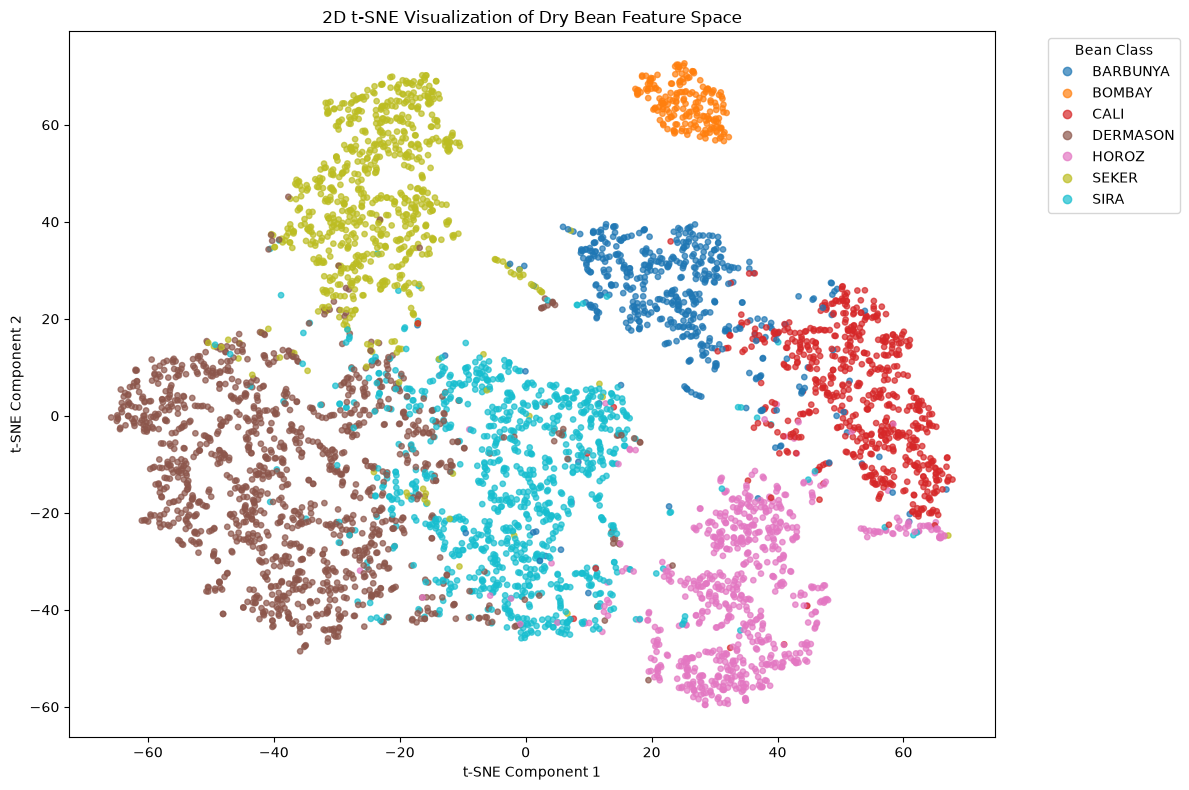

t-SNE figure saved successfully!


In [30]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    X_tsne_2d[:, 0],
    X_tsne_2d[:, 1],
    c=y_tsne,
    cmap="tab10",
    s=15,
    alpha=0.7
)

classes = label_encoder.classes_
handles, _ = scatter.legend_elements()

plt.legend(
    handles,
    classes,
    title="Bean Class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.title("2D t-SNE Visualization of Dry Bean Feature Space")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")

plt.tight_layout()

plt.savefig(
    "../figures/tsne_dry_bean.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("t-SNE figure saved successfully!")

In [31]:
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import time

In [32]:
# Linear SVM

linear_svm = SVC(
    kernel="linear",
    random_state=42
)

# Measure training time
start_time = time.perf_counter()

linear_svm.fit(X_train_scaled, y_train)

training_time_linear = time.perf_counter() - start_time

print("Linear SVM training completed!")
print(f"Training time: {training_time_linear:.4f} seconds")

Linear SVM training completed!
Training time: 1.5129 seconds


In [33]:
# Linear SVM predictions

start_time = time.perf_counter()

y_pred_linear = linear_svm.predict(X_test_scaled)

prediction_time_linear = time.perf_counter() - start_time

print("Prediction completed!")
print(f"Prediction time: {prediction_time_linear:.4f} seconds")

Prediction completed!
Prediction time: 0.4962 seconds


In [34]:
# Calculate Linear SVM performance metrics

accuracy_linear = accuracy_score(y_test, y_pred_linear)

precision_linear = precision_score(
    y_test,
    y_pred_linear,
    average="weighted",
    zero_division=0
)

recall_linear = recall_score(
    y_test,
    y_pred_linear,
    average="weighted",
    zero_division=0
)

f1_linear = f1_score(
    y_test,
    y_pred_linear,
    average="weighted",
    zero_division=0
)

print("Linear SVM Performance")
print("----------------------")
print(f"Accuracy :  {accuracy_linear:.4f}")
print(f"Precision:  {precision_linear:.4f}")
print(f"Recall   :  {recall_linear:.4f}")
print(f"F1-Score :  {f1_linear:.4f}")

Linear SVM Performance
----------------------
Accuracy :  0.9210
Precision:  0.9211
Recall   :  0.9210
F1-Score :  0.9210


In [35]:
print("Classification Report - Linear SVM")
print("-----------------------------------")

print(
    classification_report(
        y_test,
        y_pred_linear,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - Linear SVM
-----------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.90      0.91       265
      BOMBAY       1.00      0.99      1.00       104
        CALI       0.92      0.94      0.93       326
    DERMASON       0.91      0.92      0.92       709
       HOROZ       0.96      0.95      0.96       372
       SEKER       0.94      0.95      0.94       406
        SIRA       0.87      0.87      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



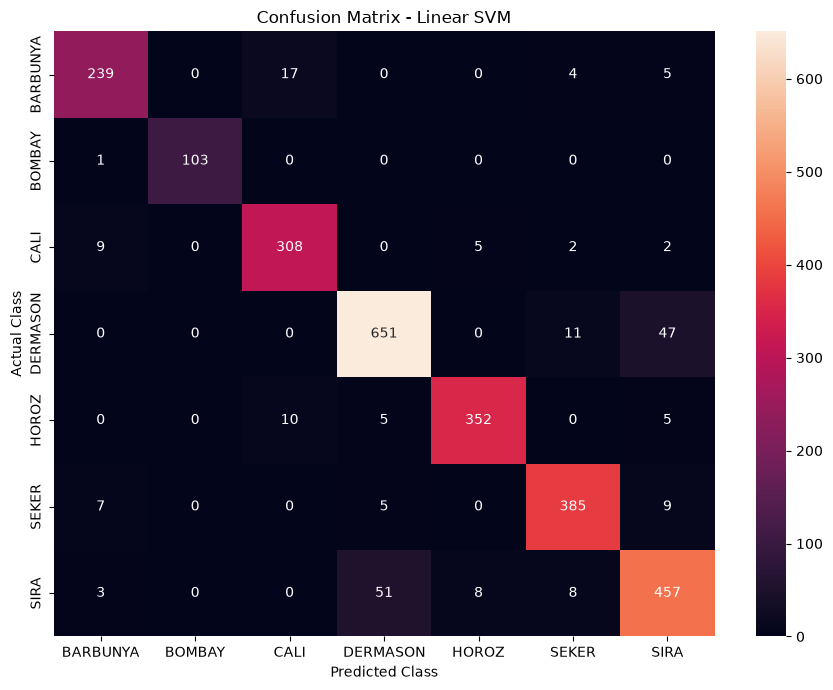

In [36]:
cm_linear = confusion_matrix(y_test, y_pred_linear)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_linear,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    "../figures/confusion_matrix_linear_svm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
linear_result = {
    "Model": "SVM - Linear",
    "Accuracy": accuracy_linear,
    "Precision": precision_linear,
    "Recall": recall_linear,
    "F1_Score": f1_linear,
    "Training_Time": training_time_linear,
    "Prediction_Time": prediction_time_linear
}

print(linear_result)

{'Model': 'SVM - Linear', 'Accuracy': 0.9210040605389442, 'Precision': 0.9210980490566268, 'Recall': 0.9210040605389442, 'F1_Score': 0.921000755078614, 'Training_Time': 1.5129219999944326, 'Prediction_Time': 0.4961856000008993}


In [38]:
# Polynomial SVM

poly_svm = SVC(
    kernel="poly",
    degree=3,
    random_state=42
)

start_time = time.perf_counter()

poly_svm.fit(X_train_scaled, y_train)

training_time_poly = time.perf_counter() - start_time

print("Polynomial SVM training completed!")
print(f"Training time: {training_time_poly:.4f} seconds")

Polynomial SVM training completed!
Training time: 2.2243 seconds


In [39]:
# Polynomial SVM predictions

start_time = time.perf_counter()

y_pred_poly = poly_svm.predict(X_test_scaled)

prediction_time_poly = time.perf_counter() - start_time

print("Prediction completed!")
print(f"Prediction time: {prediction_time_poly:.4f} seconds")

Prediction completed!
Prediction time: 0.7351 seconds


In [40]:
# Polynomial SVM performance

accuracy_poly = accuracy_score(y_test, y_pred_poly)

precision_poly = precision_score(
    y_test,
    y_pred_poly,
    average="weighted",
    zero_division=0
)

recall_poly = recall_score(
    y_test,
    y_pred_poly,
    average="weighted",
    zero_division=0
)

f1_poly = f1_score(
    y_test,
    y_pred_poly,
    average="weighted",
    zero_division=0
)

print("Polynomial SVM Performance")
print("--------------------------")
print(f"Accuracy :  {accuracy_poly:.4f}")
print(f"Precision:  {precision_poly:.4f}")
print(f"Recall   :  {recall_poly:.4f}")
print(f"F1-Score : {f1_poly:.4f}")

Polynomial SVM Performance
--------------------------
Accuracy :  0.9140
Precision:  0.9219
Recall   :  0.9140
F1-Score : 0.9155


In [41]:
print("Classification Report - Polynomial SVM")
print("--------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_poly,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - Polynomial SVM
--------------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.85      0.89       265
      BOMBAY       1.00      0.99      1.00       104
        CALI       0.95      0.93      0.94       326
    DERMASON       0.95      0.88      0.91       709
       HOROZ       0.97      0.93      0.95       372
       SEKER       0.96      0.93      0.95       406
        SIRA       0.77      0.94      0.85       527

    accuracy                           0.91      2709
   macro avg       0.94      0.92      0.93      2709
weighted avg       0.92      0.91      0.92      2709



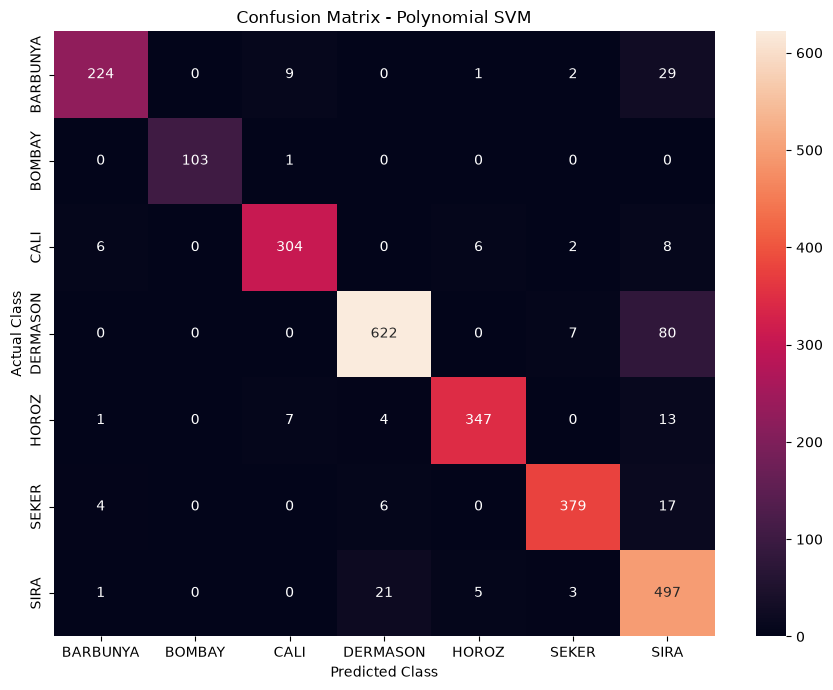

In [42]:
cm_poly = confusion_matrix(y_test, y_pred_poly)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_poly,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Polynomial SVM")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    "../figures/confusion_matrix_polynomial_svm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [43]:
poly_result = {
    "Model": "SVM - Polynomial",
    "Accuracy": accuracy_poly,
    "Precision": precision_poly,
    "Recall": recall_poly,
    "F1_Score": f1_poly,
    "Training_Time": training_time_poly,
    "Prediction_Time": prediction_time_poly
}

print(poly_result)

{'Model': 'SVM - Polynomial', 'Accuracy': 0.9139904023624954, 'Precision': 0.921894058327863, 'Recall': 0.9139904023624954, 'F1_Score': 0.9154916986351318, 'Training_Time': 2.2243209999869578, 'Prediction_Time': 0.7350595000025351}


In [44]:
# RBF SVM

rbf_svm = SVC(
    kernel="rbf",
    random_state=42
)

start_time = time.perf_counter()

rbf_svm.fit(X_train_scaled, y_train)

training_time_rbf = time.perf_counter() - start_time

print("RBF SVM training completed!")
print(f"Training time: {training_time_rbf:.4f} seconds")

RBF SVM training completed!
Training time: 2.3332 seconds


In [45]:
# RBF SVM predictions

start_time = time.perf_counter()

y_pred_rbf = rbf_svm.predict(X_test_scaled)

prediction_time_rbf = time.perf_counter() - start_time

print("Prediction completed!")
print(f"Prediction time: {prediction_time_rbf:.4f} seconds")

Prediction completed!
Prediction time: 1.7775 seconds


In [46]:
# RBF SVM performance

accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

precision_rbf = precision_score(
    y_test,
    y_pred_rbf,
    average="weighted",
    zero_division=0
)

recall_rbf = recall_score(
    y_test,
    y_pred_rbf,
    average="weighted",
    zero_division=0
)

f1_rbf = f1_score(
    y_test,
    y_pred_rbf,
    average="weighted",
    zero_division=0
)

print("RBF SVM Performance")
print("-------------------")
print(f"Accuracy :  {accuracy_rbf:.4f}")
print(f"Precision:  {precision_rbf:.4f}")
print(f"Recall   :  {recall_rbf:.4f}")
print(f"F1-Score : {f1_rbf:.4f}")

RBF SVM Performance
-------------------
Accuracy :  0.9210
Precision:  0.9214
Recall   :  0.9210
F1-Score : 0.9211


In [47]:
print("Classification Report - RBF SVM")
print("--------------------------------")

print(
    classification_report(
        y_test,
        y_pred_rbf,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - RBF SVM
--------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.95      0.93       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.95      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



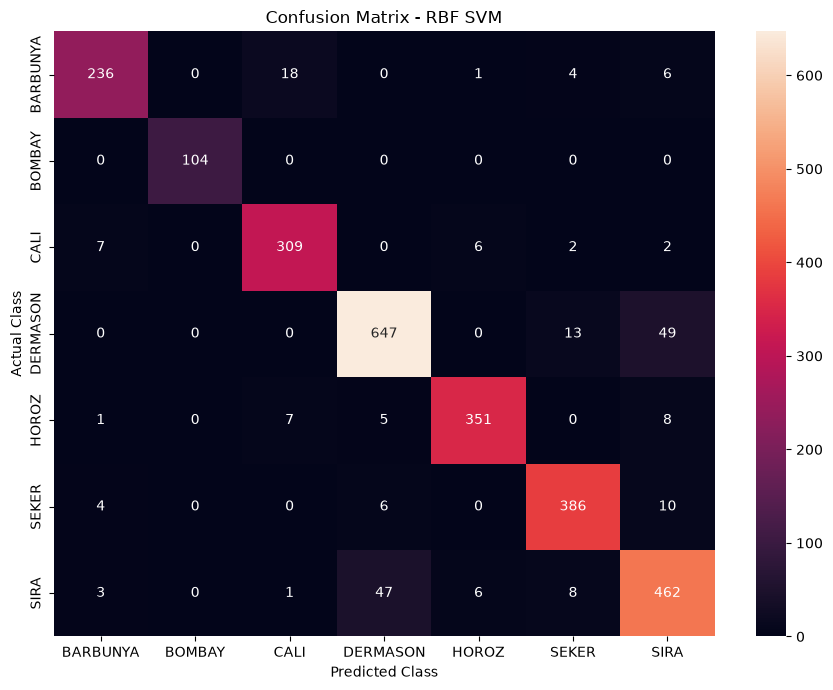

In [48]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_rbf,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - RBF SVM")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    "../figures/confusion_matrix_rbf_svm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
rbf_result = {
    "Model": "SVM - RBF",
    "Accuracy": accuracy_rbf,
    "Precision": precision_rbf,
    "Recall": recall_rbf,
    "F1_Score": f1_rbf,
    "Training_Time": training_time_rbf,
    "Prediction_Time": prediction_time_rbf
}

print(rbf_result)

{'Model': 'SVM - RBF', 'Accuracy': 0.9210040605389442, 'Precision': 0.9214106079511519, 'Recall': 0.9210040605389442, 'F1_Score': 0.9210779160652252, 'Training_Time': 2.333214499987662, 'Prediction_Time': 1.7774801999912597}


In [50]:
svm_results = pd.DataFrame([
    linear_result,
    poly_result,
    rbf_result
])

svm_results

,Model,Accuracy,Precision,Recall,F1_Score,Training_Time,Prediction_Time
0,SVM - Linear,0.921004,0.921098,0.921004,0.921001,1.512922,0.496186
1,SVM - Polynomial,0.913990,0.921894,0.913990,0.915492,2.224321,0.735060
2,SVM - RBF,0.921004,0.921411,0.921004,0.921078,2.333214,1.777480


In [51]:
import os

os.makedirs("../results", exist_ok=True)

svm_results.to_csv(
    "../results/SVM_Comparison.csv",
    index=False
)

print("SVM comparison saved successfully!")

SVM comparison saved successfully!


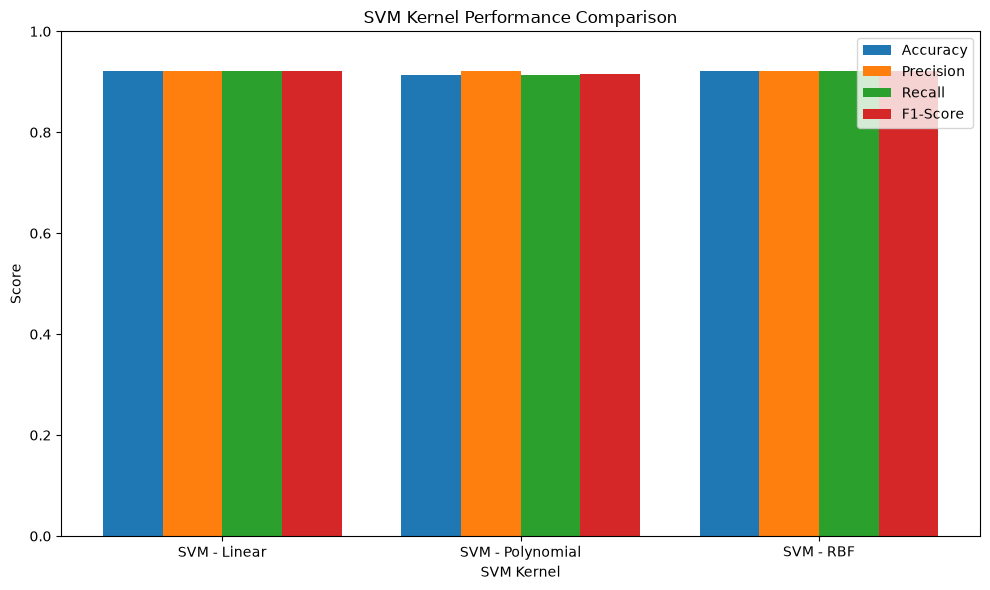

In [52]:
plt.figure(figsize=(10, 6))

x = np.arange(len(svm_results))
width = 0.2

plt.bar(x - 1.5 * width, svm_results["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5 * width, svm_results["Precision"], width, label="Precision")
plt.bar(x + 0.5 * width, svm_results["Recall"], width, label="Recall")
plt.bar(x + 1.5 * width, svm_results["F1_Score"], width, label="F1-Score")

plt.xticks(x, svm_results["Model"])
plt.ylabel("Score")
plt.xlabel("SVM Kernel")
plt.title("SVM Kernel Performance Comparison")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/svm_kernel_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
svm_results

,Model,Accuracy,Precision,Recall,F1_Score,Training_Time,Prediction_Time
0,SVM - Linear,0.921004,0.921098,0.921004,0.921001,1.512922,0.496186
1,SVM - Polynomial,0.913990,0.921894,0.913990,0.915492,2.224321,0.735060
2,SVM - RBF,0.921004,0.921411,0.921004,0.921078,2.333214,1.777480


In [54]:
from sklearn.tree import DecisionTreeClassifier

In [55]:
max_depth_values = [5, 10, 15, 20]
min_samples_split_values = [2, 10, 20]

print("Max depth values:", max_depth_values)
print("Min samples split values:", min_samples_split_values)

Max depth values: [5, 10, 15, 20]
Min samples split values: [2, 10, 20]


In [56]:
import time

decision_tree_results = []

for max_depth in max_depth_values:
    for min_samples_split in min_samples_split_values:

        print(
            f"Training Decision Tree: "
            f"max_depth={max_depth}, "
            f"min_samples_split={min_samples_split}"
        )

        # Create model
        dt_model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42
        )

        # Measure training time
        start_time = time.perf_counter()

        dt_model.fit(X_train, y_train)

        training_time = time.perf_counter() - start_time

        # Measure prediction time
        start_time = time.perf_counter()

        y_pred_dt = dt_model.predict(X_test)

        prediction_time = time.perf_counter() - start_time

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred_dt)

        precision = precision_score(
            y_test,
            y_pred_dt,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred_dt,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred_dt,
            average="weighted",
            zero_division=0
        )

        # Store results
        decision_tree_results.append({
            "Model": "Decision Tree",
            "max_depth": max_depth,
            "min_samples_split": min_samples_split,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "Training_Time": training_time,
            "Prediction_Time": prediction_time
        })

print("\nAll Decision Tree experiments completed!")

Training Decision Tree: max_depth=5, min_samples_split=2
Training Decision Tree: max_depth=5, min_samples_split=10
Training Decision Tree: max_depth=5, min_samples_split=20
Training Decision Tree: max_depth=10, min_samples_split=2
Training Decision Tree: max_depth=10, min_samples_split=10
Training Decision Tree: max_depth=10, min_samples_split=20
Training Decision Tree: max_depth=15, min_samples_split=2
Training Decision Tree: max_depth=15, min_samples_split=10
Training Decision Tree: max_depth=15, min_samples_split=20
Training Decision Tree: max_depth=20, min_samples_split=2
Training Decision Tree: max_depth=20, min_samples_split=10
Training Decision Tree: max_depth=20, min_samples_split=20

All Decision Tree experiments completed!


In [57]:
decision_tree_results_df = pd.DataFrame(decision_tree_results)

decision_tree_results_df

,Model,max_depth,min_samples_split,Accuracy,Precision,Recall,F1_Score,Training_Time,Prediction_Time
0,Decision Tree,5,2,0.874862,0.882394,0.874862,0.875483,0.110805,0.002902
1,Decision Tree,5,10,0.874862,0.882394,0.874862,0.875483,0.158388,0.018378
2,Decision Tree,5,20,0.874862,0.882394,0.874862,0.875483,0.101047,0.001752
3,Decision Tree,10,2,0.902178,0.902521,0.902178,0.902262,0.191011,0.002169
4,Decision Tree,10,10,0.903654,0.903948,0.903654,0.903641,0.180223,0.001777
5,Decision Tree,10,20,0.904762,0.905063,0.904762,0.904717,0.208485,0.002637
6,Decision Tree,15,2,0.902916,0.902956,0.902916,0.902871,0.258642,0.002978
7,Decision Tree,15,10,0.906977,0.906821,0.906977,0.906757,0.226710,0.001890
8,Decision Tree,15,20,0.908822,0.908626,0.908822,0.908552,0.206698,0.001706
9,Decision Tree,20,2,0.898117,0.897892,0.898117,0.897901,0.209095,0.002298


In [58]:
import os

os.makedirs("../results", exist_ok=True)

decision_tree_results_df.to_csv(
    "../results/Decision_Tree_Comparison.csv",
    index=False
)

print("Decision Tree results saved successfully!")

Decision Tree results saved successfully!


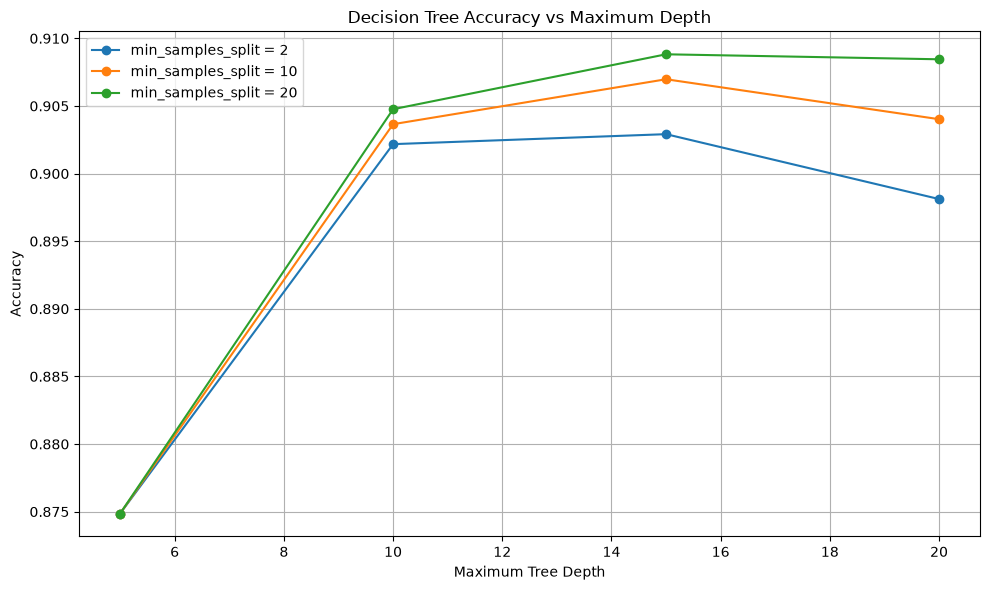

In [59]:
plt.figure(figsize=(10, 6))

for split_value in min_samples_split_values:

    subset = decision_tree_results_df[
        decision_tree_results_df["min_samples_split"] == split_value
    ]

    plt.plot(
        subset["max_depth"],
        subset["Accuracy"],
        marker="o",
        label=f"min_samples_split = {split_value}"
    )

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Maximum Depth")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/decision_tree_depth_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

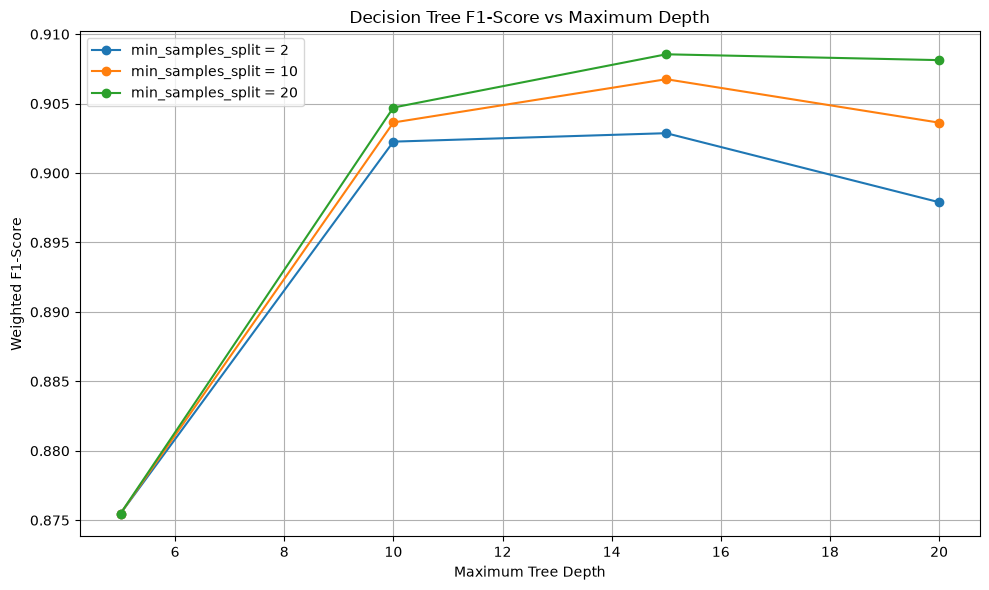

In [60]:
plt.figure(figsize=(10, 6))

for split_value in min_samples_split_values:

    subset = decision_tree_results_df[
        decision_tree_results_df["min_samples_split"] == split_value
    ]

    plt.plot(
        subset["max_depth"],
        subset["F1_Score"],
        marker="o",
        label=f"min_samples_split = {split_value}"
    )

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Weighted F1-Score")
plt.title("Decision Tree F1-Score vs Maximum Depth")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/decision_tree_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [61]:
decision_tree_results_df

,Model,max_depth,min_samples_split,Accuracy,Precision,Recall,F1_Score,Training_Time,Prediction_Time
0,Decision Tree,5,2,0.874862,0.882394,0.874862,0.875483,0.110805,0.002902
1,Decision Tree,5,10,0.874862,0.882394,0.874862,0.875483,0.158388,0.018378
2,Decision Tree,5,20,0.874862,0.882394,0.874862,0.875483,0.101047,0.001752
3,Decision Tree,10,2,0.902178,0.902521,0.902178,0.902262,0.191011,0.002169
4,Decision Tree,10,10,0.903654,0.903948,0.903654,0.903641,0.180223,0.001777
5,Decision Tree,10,20,0.904762,0.905063,0.904762,0.904717,0.208485,0.002637
6,Decision Tree,15,2,0.902916,0.902956,0.902916,0.902871,0.258642,0.002978
7,Decision Tree,15,10,0.906977,0.906821,0.906977,0.906757,0.226710,0.001890
8,Decision Tree,15,20,0.908822,0.908626,0.908822,0.908552,0.206698,0.001706
9,Decision Tree,20,2,0.898117,0.897892,0.898117,0.897901,0.209095,0.002298


In [62]:
# Decision Tree for detailed evaluation

final_dt = DecisionTreeClassifier(
    max_depth=15,
    min_samples_split=20,
    random_state=42
)

start_time = time.perf_counter()

final_dt.fit(X_train, y_train)

final_dt_training_time = time.perf_counter() - start_time

print("Decision Tree training completed!")
print(f"Training time: {final_dt_training_time:.4f} seconds")

Decision Tree training completed!
Training time: 0.5744 seconds


In [63]:
start_time = time.perf_counter()

y_pred_dt = final_dt.predict(X_test)

final_dt_prediction_time = time.perf_counter() - start_time

print("Prediction completed!")
print(f"Prediction time: {final_dt_prediction_time:.4f} seconds")

Prediction completed!
Prediction time: 0.0068 seconds


In [64]:
final_dt_accuracy = accuracy_score(y_test, y_pred_dt)

final_dt_precision = precision_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

final_dt_recall = recall_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

final_dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    average="weighted",
    zero_division=0
)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy :  {final_dt_accuracy:.4f}")
print(f"Precision:  {final_dt_precision:.4f}")
print(f"Recall   :  {final_dt_recall:.4f}")
print(f"F1-Score : {final_dt_f1:.4f}")

Decision Tree Performance
-------------------------
Accuracy :  0.9088
Precision:  0.9086
Recall   :  0.9088
F1-Score : 0.9086


In [65]:
print("Classification Report - Decision Tree")
print("-------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Classification Report - Decision Tree
-------------------------------------
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.90      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.93      0.92       326
    DERMASON       0.89      0.92      0.91       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.92      0.94      0.93       406
        SIRA       0.86      0.82      0.84       527

    accuracy                           0.91      2709
   macro avg       0.92      0.92      0.92      2709
weighted avg       0.91      0.91      0.91      2709



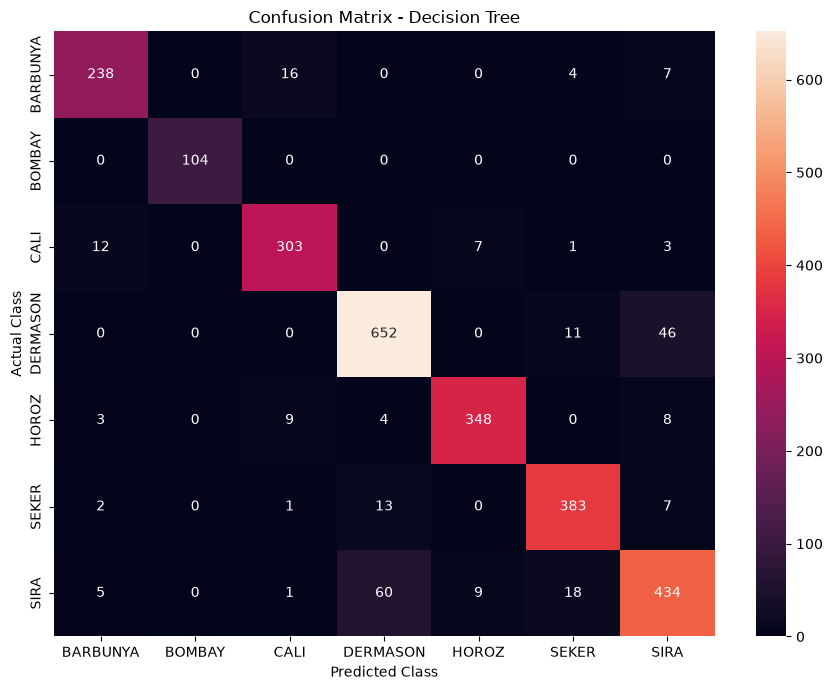

In [66]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    "../figures/confusion_matrix_decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
final_dt_result = {
    "Model": "Decision Tree",
    "max_depth": 15,
    "min_samples_split": 20,
    "Accuracy": final_dt_accuracy,
    "Precision": final_dt_precision,
    "Recall": final_dt_recall,
    "F1_Score": final_dt_f1,
    "Training_Time": final_dt_training_time,
    "Prediction_Time": final_dt_prediction_time
}

print(final_dt_result)

{'Model': 'Decision Tree', 'max_depth': 15, 'min_samples_split': 20, 'Accuracy': 0.9088224437061646, 'Precision': 0.9086263726440919, 'Recall': 0.9088224437061646, 'F1_Score': 0.9085516521274907, 'Training_Time': 0.5744035999814514, 'Prediction_Time': 0.006758700008504093}


In [68]:
final_dt_result

{'Model': 'Decision Tree',
 'max_depth': 15,
 'min_samples_split': 20,
 'Accuracy': 0.9088224437061646,
 'Precision': 0.9086263726440919,
 'Recall': 0.9088224437061646,
 'F1_Score': 0.9085516521274907,
 'Training_Time': 0.5744035999814514,
 'Prediction_Time': 0.006758700008504093}

In [69]:
# Final comparison of SVM and Decision Tree models

final_model_results = pd.DataFrame([
    linear_result,
    poly_result,
    rbf_result,
    final_dt_result
])

final_model_results

,Model,Accuracy,Precision,Recall,F1_Score,Training_Time,Prediction_Time,max_depth,min_samples_split
0,SVM - Linear,0.921004,0.921098,0.921004,0.921001,1.512922,0.496186,NaN,NaN
1,SVM - Polynomial,0.913990,0.921894,0.913990,0.915492,2.224321,0.735060,NaN,NaN
2,SVM - RBF,0.921004,0.921411,0.921004,0.921078,2.333214,1.777480,NaN,NaN
3,Decision Tree,0.908822,0.908626,0.908822,0.908552,0.574404,0.006759,15.0,20.0


In [70]:
final_model_results.to_csv(
    "../results/Final_Model_Comparison.csv",
    index=False
)

print("Final model comparison saved successfully.")

Final model comparison saved successfully.


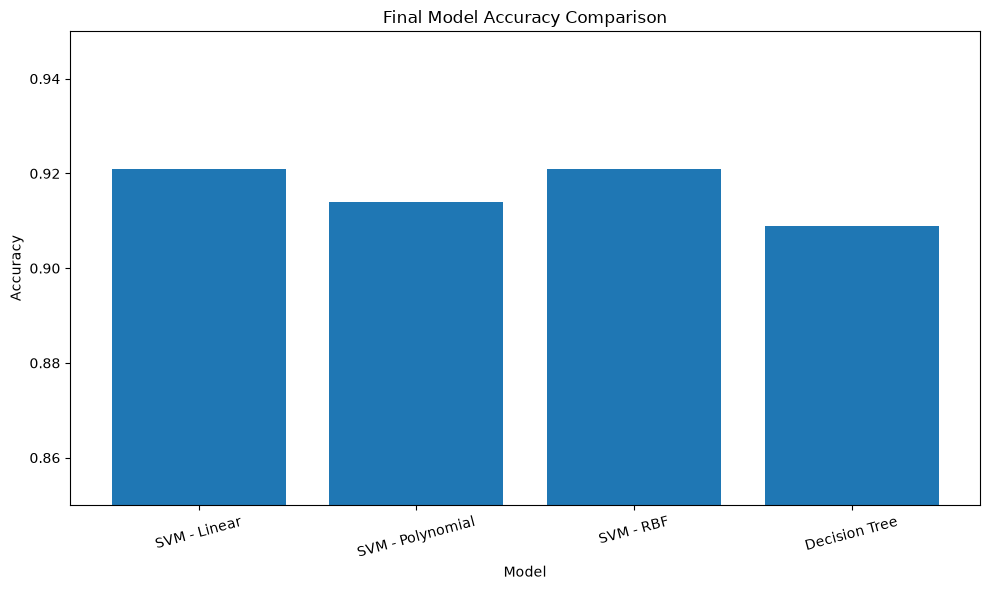

Final comparison chart saved successfully.


In [71]:
import matplotlib.pyplot as plt

# Extract model names and accuracy
models = final_model_results["Model"]
accuracies = final_model_results["Accuracy"]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Final Model Accuracy Comparison")
plt.ylim(0.85, 0.95)
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig("../figures/final_model_comparison.png", dpi=300)
plt.show()

print("Final comparison chart saved successfully.")

In [72]:
final_model_results.round(6)

,Model,Accuracy,Precision,Recall,F1_Score,Training_Time,Prediction_Time,max_depth,min_samples_split
0,SVM - Linear,0.921004,0.921098,0.921004,0.921001,1.512922,0.496186,NaN,NaN
1,SVM - Polynomial,0.913990,0.921894,0.913990,0.915492,2.224321,0.735060,NaN,NaN
2,SVM - RBF,0.921004,0.921411,0.921004,0.921078,2.333214,1.777480,NaN,NaN
3,Decision Tree,0.908822,0.908626,0.908822,0.908552,0.574404,0.006759,15.0,20.0


In [73]:
print("Final results files:")
print("../results/Final_Model_Comparison.csv")
print("../figures/final_model_comparison.png")

Final results files:
../results/Final_Model_Comparison.csv
../figures/final_model_comparison.png
